# Cardiovascular Health Prediction

This project aims to use patient data collected by researchers in India to predict whether a hypothetical patient has heart disease. Original data split into training and test sets will be used to train ML models, the best of which will later be used in a Streamlit app to allow users to classify a hypothetical patient's risk for heart disease. Contributors to the original journal article are Bhanu Prakash Doppala, Debnath Bhattacharyya, Midhunchakkaravarthy Janarthanan, and Namkyun Baik.

The journal article detailing the researcher's original methodology and findings is linked here: https://onlinelibrary.wiley.com/doi/10.1155/2022/2585235

The data and data description files can be found here: https://data.mendeley.com/datasets/dzz48mvjht/1

In [10]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
data_file = pd.read_csv('https://github.com/akozikow/Cardiovascular_Health/raw/refs/heads/main/Cardiovascular_Disease_Dataset.csv')
data_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patientid          1000 non-null   int64  
 1   age                1000 non-null   int64  
 2   gender             1000 non-null   int64  
 3   chestpain          1000 non-null   int64  
 4   restingBP          1000 non-null   int64  
 5   serumcholestrol    1000 non-null   int64  
 6   fastingbloodsugar  1000 non-null   int64  
 7   restingrelectro    1000 non-null   int64  
 8   maxheartrate       1000 non-null   int64  
 9   exerciseangia      1000 non-null   int64  
 10  oldpeak            1000 non-null   float64
 11  slope              1000 non-null   int64  
 12  noofmajorvessels   1000 non-null   int64  
 13  target             1000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 109.5 KB


We can see above that we are benefiting from a clean dataset. This makes sense for a published data set, so we won't need to worry as much about missing values. The accompanying data description document tells us what each feature is and the values it can take. Below is a brief summary of that document.

In [11]:
data_description = pd.DataFrame({'Feature Name' : data_file.columns.tolist(),
                                 'Attribute' : ['Patient Identification Number', 'Age', 'Gender', 'Chest Pain Type', 'Resting  Blood Pressure (mm HG)', 'Serum Cholseterol (mg/dl)', 'Fasting Blood Sugar > 120 mg/ml', 'Resting electrocardiogram results', 'maximum heart rate achieved (BPM)', 'Exercised induced angina', 'Oldpeak = ST', 'Slope of the peak exercise ST segment', 'number of major vessels', 'Classification'],
                                'Possible Values': ['Integers', 'Integers', '0, 1', '0, 1, 2, 3', 'Integers: 94-200', 'Integers: 126-564', '0,1', '0, 1, 2', 'Integers: 71-202', '0, 1', 'Float: 0-6.2', '1, 2, 3', '0, 1, 2, 3', '0, 1' ]})
data_description

,Feature Name,Attribute,Possible Values
0,patientid,Patient Identification Number,Integers
1,age,Age,Integers
2,gender,Gender,"0, 1"
3,chestpain,Chest Pain Type,"0, 1, 2, 3"
4,restingBP,Resting Blood Pressure (mm HG),Integers: 94-200
5,serumcholestrol,Serum Cholseterol (mg/dl),Integers: 126-564
6,fastingbloodsugar,Fasting Blood Sugar > 120 mg/ml,"0,1"
7,restingrelectro,Resting electrocardiogram results,"0, 1, 2"
8,maxheartrate,maximum heart rate achieved (BPM),Integers: 71-202
9,exerciseangia,Exercised induced angina,"0, 1"


For Gender, 0=Female and 1=Male. For chest pain, 0, 1, 2, and 3 indicate typical angina, atypical angina, non-angina chest pain, and asymptomatic respectively; angina is a type of chest pain caused by a lack of oxygen in the chest muscles. For Resting elecgtrocardiogram results, 0 is normal (no issues), 1 indicates ST/T wave abnormalities, and 2 indicates probably or definite left ventricular hypertrophy. slope feature values of 1, 2, or 3 indicates upsoping, flat, or downsloping of the peak exercise ST segment. For other features with (0, 1) as possbible values, 0 indicates false and 1 indicates true.

Besides reading what each of the features meant and values they could take, I wanted to avoid reading too much about the researcher's methodology to avoid absorbing too much of thier methodologies in designing thier models, as I wanted to find my own way in this exercise. That said, I did research some of the features to learn more about them and what kind of impact they might have on cardiovascular health.

One thing that immediately concerns me about the dataset is the ordinal encoding of some features, e.g. the 'slope' feature. After some quick research, the consensus is that a horizontal (value 2) or downward slope (value 3) of the peak exercise ST segment indicate a higher risk for ischemia. However, it is hard to quantify by how much, and whether or not this incrased ischemia is greater for patients with horizontal or downsloping ST segments. For this reason, i feel that One Hot Encoding is more appropriate for features such as 'chestpain', 'restingelectro', and 'slope'.

## Exploratory Data Analysis

Despite the fact that this is a curated, cleaned dataset that we are looking at, its a good idea to take a look first to get an idea of how the various features are distributed.

Text(0, 0.5, '')

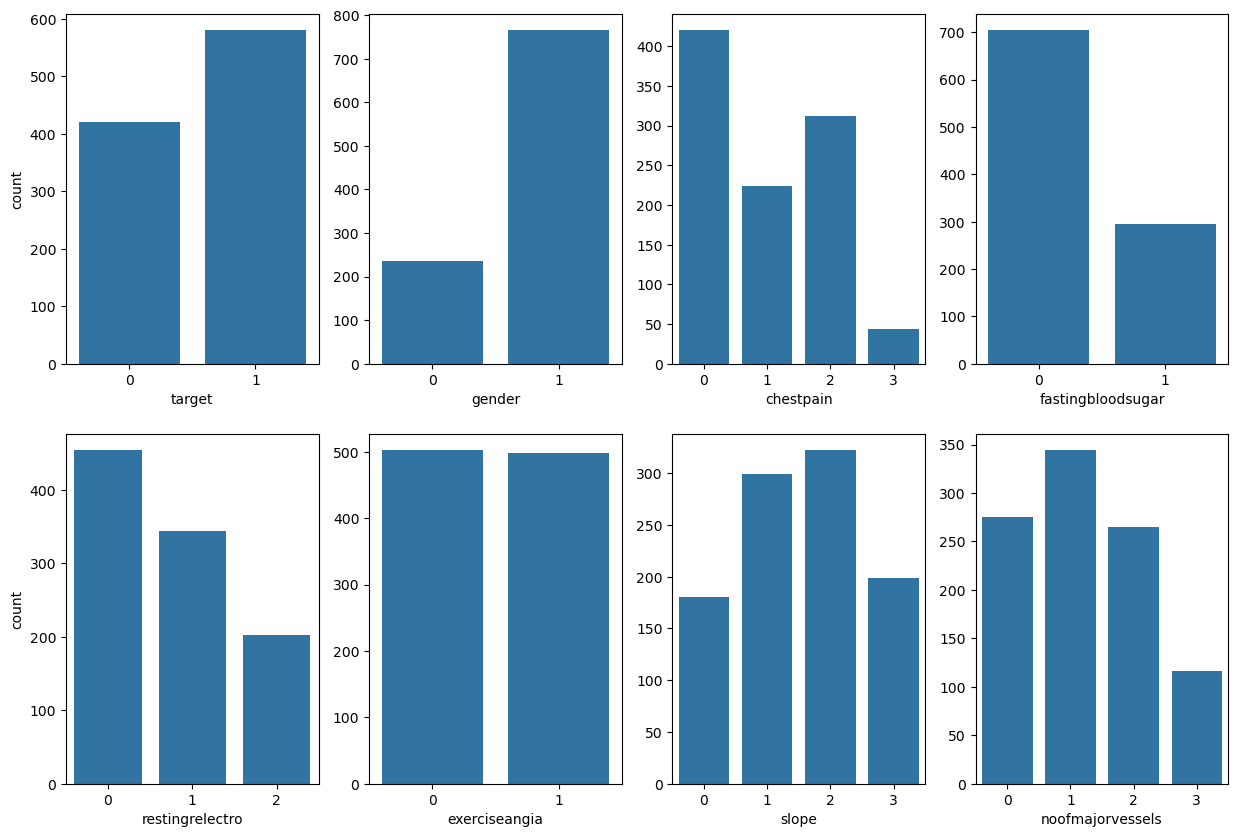

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize = (15, 10))
plt.subplot(2, 4, 1)
sns.barplot(data_file['target'].value_counts())
plt.subplot(2, 4, 2)
sns.barplot(data_file['gender'].value_counts())
plt.ylabel('')
plt.subplot(2, 4, 3)
sns.barplot(data_file['chestpain'].value_counts())
plt.ylabel('')
plt.subplot(2, 4, 4)
sns.barplot(data_file['fastingbloodsugar'].value_counts())
plt.ylabel('')
plt.subplot(2, 4, 5)
sns.barplot(data_file['restingrelectro'].value_counts())
plt.subplot(2, 4, 6)
sns.barplot(data_file['exerciseangia'].value_counts())
plt.ylabel('')
plt.subplot(2, 4, 7)
sns.barplot(data_file['slope'].value_counts())
plt.ylabel('')
plt.subplot(2, 4, 8)
sns.barplot(data_file['noofmajorvessels'].value_counts())
plt.ylabel('')

We can see here that for most features, there are not too many rare classes. The rarest class is class 3 in the "chestpain" feature, which indicates an asymptomatic patient. We can also see here that men are overrerpresented in this dataset, with rougly 3/4 of the dataset being men. Strangely, we can see 'slope' has a 0 class when the data description file only discussed 1, 2, 3 as possible classes. This is not discussed in the paper, and we will make the assumption that this 0 is a "typical" class.

Text(0.5, 1.0, 'Resting Blood Pressure Histogram')

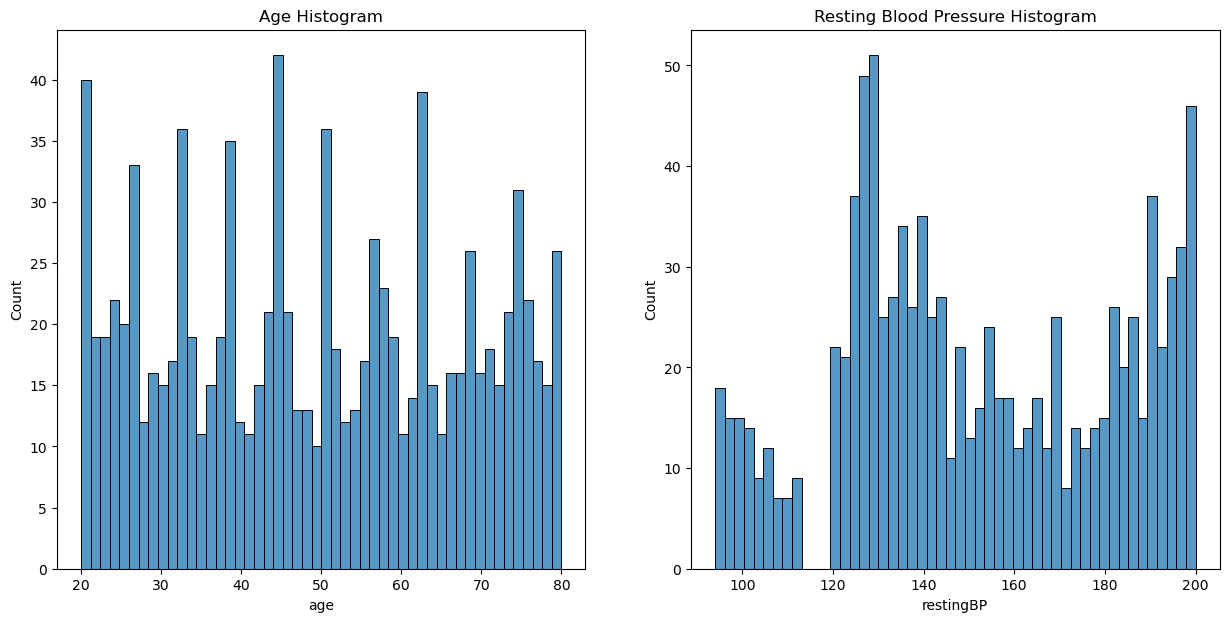

In [13]:
plt.figure(figsize = (15, 7))
plt.subplot(1, 2, 1)
sns.histplot(data_file['age'], bins = 50)
plt.title('Age Histogram')
plt.subplot(1, 2, 2)
sns.histplot(data_file['restingBP'], bins = 50)
plt.title('Resting Blood Pressure Histogram')

Looking at Age and Resting Blood Pressure, it is clear that these features are not normally distributed. This may make them less suitable for parametric approaches like logistic regression.

Text(0.5, 1.0, 'Max Heart Rate Histogram')

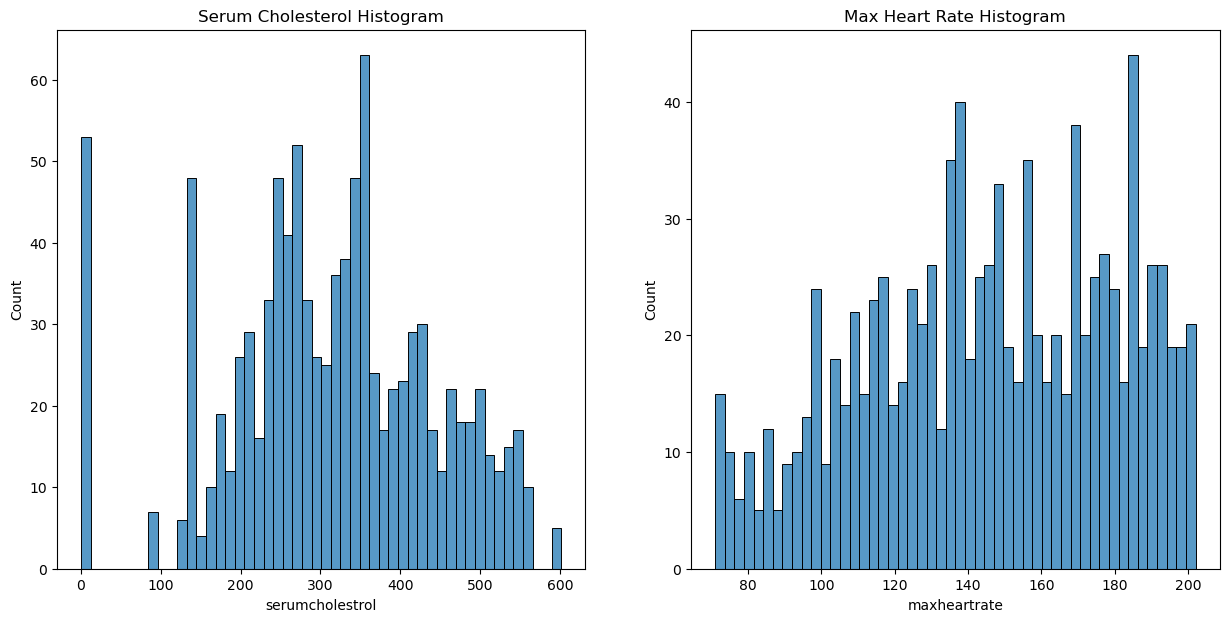

In [14]:
plt.figure(figsize = (15, 7))
plt.subplot(1, 2, 1)
sns.histplot(data_file['serumcholestrol'], bins = 50)
plt.title('Serum Cholesterol Histogram')
plt.subplot(1, 2, 2)
sns.histplot(data_file['maxheartrate'], bins = 50)
plt.title('Max Heart Rate Histogram')

When looking at the Serum Cholesterol and Max Heart Rate histograms, one thing jumps out immediately. A Serum Cholesterol of 0 is not medically possible, so these ~50 entries are likely using placeholder values. This represents 5% of our dataset, so we will have to decide what to do with these entires. Other than that, it seems to be mostly normally distributed. Max Heart Rate has negative skewness, which a log transform would help to address.

Text(0.5, 1.0, 'Oldpeak Histogram')

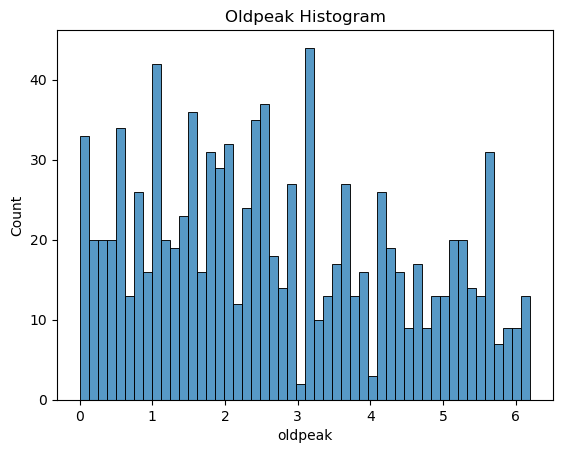

In [15]:
sns.histplot(data_file['oldpeak'], bins = 50)
plt.title('Oldpeak Histogram')

The oldpeak feature refers to exercise induced ST depression, which is measured in millimiters. Larger values indicate of ischemia. Here we can see that the data is mostly uniformly distributed, with a slight positive skewness.

## Data Preparation: One Hot Encoding

Being that we wil only remove 53 entries by omitting entries with a serum cholesterol of 0, we will simply exclude them from the dataset. We could alternatively use imputers to generate alternate values for these entries, but it seems sensible to avoid creating data values if we can help it. Below, we prepare the data for modeling by using a OneHotEncoder to transform the object features (e.g., 'chestpain', 'restingrelectro', and 'slope'). I belive this will reduce the chance of the ML algorithms we use later getting confused by an inherent implication of value by the previous ordinal encoding that was used.

In [17]:
data_file = data_file.astype({'gender':'object','chestpain' : 'object', 'fastingbloodsugar' : 'object', 'restingrelectro' : 'object', 'exerciseangia' : 'object', 'slope' : 'object'})
data_file = data_file.drop(columns = 'patientid', axis = 1)
data_file = data_file[data_file['serumcholestrol'] != 0] #remove entries with 0 serum cholesterol

In [18]:
data_file.info()

<class 'pandas.core.frame.DataFrame'>
Index: 947 entries, 1 to 999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                947 non-null    int64  
 1   gender             947 non-null    object 
 2   chestpain          947 non-null    object 
 3   restingBP          947 non-null    int64  
 4   serumcholestrol    947 non-null    int64  
 5   fastingbloodsugar  947 non-null    object 
 6   restingrelectro    947 non-null    object 
 7   maxheartrate       947 non-null    int64  
 8   exerciseangia      947 non-null    object 
 9   oldpeak            947 non-null    float64
 10  slope              947 non-null    object 
 11  noofmajorvessels   947 non-null    int64  
 12  target             947 non-null    int64  
dtypes: float64(1), int64(6), object(6)
memory usage: 103.6+ KB


In [19]:
from sklearn.model_selection import train_test_split
target = data_file['target']
data_file = data_file.drop(columns = 'target', axis = 1)
X_temp, X_test, y_temp, y_test = train_test_split(data_file, target, random_state = 42, test_size = 0.15)
X_train, X_val, y_train, y_val  = train_test_split(X_temp, y_temp, random_state = 42, test_size = 0.15)

In [20]:
print(f'Length of Training Set: {len(X_train)}')
print(f'Length of Validation Set: {len(X_val)}')
print(f'Length of Test Set: {len(X_test)}')

Length of Training Set: 683
Length of Validation Set: 121
Length of Test Set: 143


In [21]:
import numpy as np
obj_cols = X_train.select_dtypes(include = 'object').columns.to_list()
num_cols = X_train.select_dtypes(include = np.number).columns.to_list()

In [22]:
from sklearn.preprocessing import OneHotEncoder
def XformOHE(data, num_cols, obj_cols):
    num_data = data[num_cols]
    obj_data = data[obj_cols]
    encoder = OneHotEncoder(sparse_output = False)
    obj_data = encoder.fit_transform(obj_data)
    obj_data = pd.DataFrame(obj_data, columns = encoder.get_feature_names_out(obj_cols))
    obj_data.index = data.index
    xformed_data = pd.concat([num_data, obj_data], axis = 1)
    return xformed_data

In [23]:
X_train = XformOHE(X_train, num_cols, obj_cols)
X_val = XformOHE(X_val, num_cols, obj_cols)
X_test = XformOHE(X_test, num_cols, obj_cols)

In [24]:
X_train.head(3)

,age,restingBP,serumcholestrol,maxheartrate,oldpeak,noofmajorvessels,gender_0,gender_1,chestpain_0,chestpain_1,...,fastingbloodsugar_1,restingrelectro_0,restingrelectro_1,restingrelectro_2,exerciseangia_0,exerciseangia_1,slope_0,slope_1,slope_2,slope_3
705,22,186,334,167,4.1,3,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
29,49,192,521,133,2.9,2,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
131,44,100,132,128,2.2,0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [25]:
X_val.head(3)

,age,restingBP,serumcholestrol,maxheartrate,oldpeak,noofmajorvessels,gender_0,gender_1,chestpain_0,chestpain_1,...,fastingbloodsugar_1,restingrelectro_0,restingrelectro_1,restingrelectro_2,exerciseangia_0,exerciseangia_1,slope_0,slope_1,slope_2,slope_3
870,44,138,471,142,4.5,2,0.0,1.0,1.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
867,79,143,219,90,1.3,2,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
194,62,125,264,92,2.2,0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [26]:
X_test.head(3)

,age,restingBP,serumcholestrol,maxheartrate,oldpeak,noofmajorvessels,gender_0,gender_1,chestpain_0,chestpain_1,...,fastingbloodsugar_1,restingrelectro_0,restingrelectro_1,restingrelectro_2,exerciseangia_0,exerciseangia_1,slope_0,slope_1,slope_2,slope_3
629,43,145,207,186,0.6,0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
984,33,124,182,130,1.8,0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
151,32,163,239,164,0.7,3,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


After one hot encoding, we will take a look at the correlation matrix of the data.

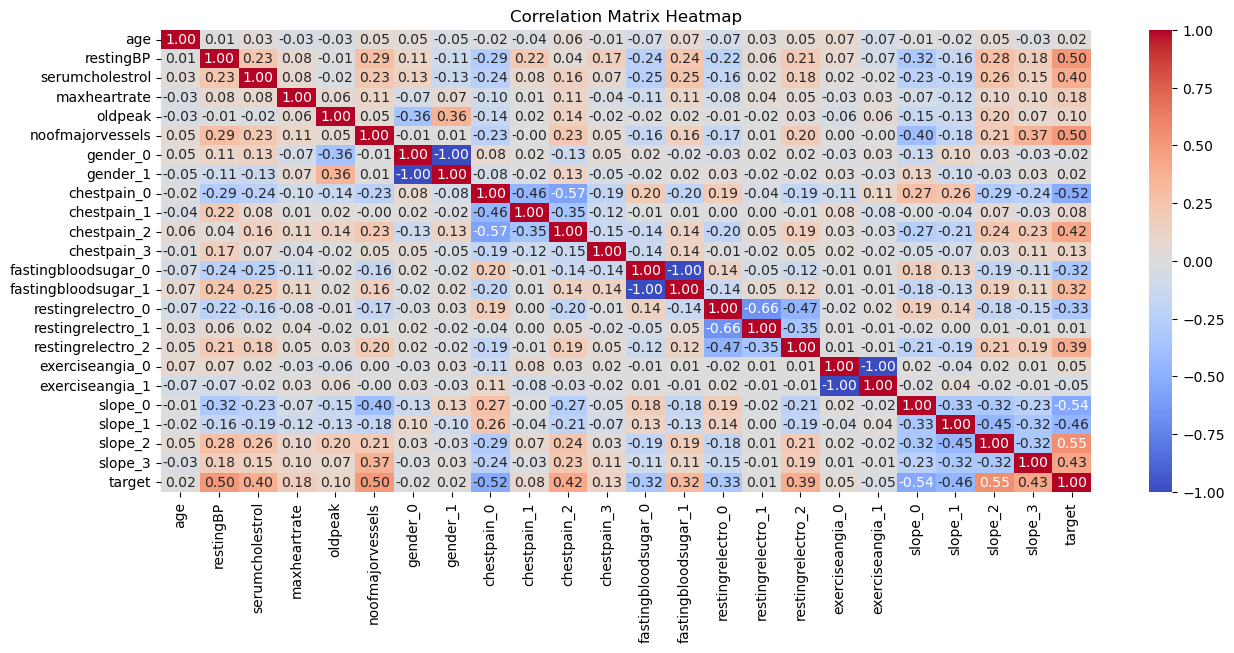

In [41]:
corr_data = pd.concat([X_train, y_train], axis = 1)
corr_matrix = corr_data.corr()
plt.figure(figsize=(15, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

In [46]:
corr_data.corr()['target'].drop('target').sort_values(ascending = False)

slope_2                0.554175
restingBP              0.504098
noofmajorvessels       0.499478
slope_3                0.432173
chestpain_2            0.422094
serumcholestrol        0.395340
restingrelectro_2      0.394932
fastingbloodsugar_1    0.322224
maxheartrate           0.178913
chestpain_3            0.128859
oldpeak                0.103434
chestpain_1            0.083718
exerciseangia_0        0.049142
gender_1               0.015902
age                    0.015827
restingrelectro_1      0.009965
gender_0              -0.015902
exerciseangia_1       -0.049142
fastingbloodsugar_0   -0.322224
restingrelectro_0     -0.325388
slope_1               -0.459125
chestpain_0           -0.518280
slope_0               -0.541367
Name: target, dtype: float64

From the correlation matrix, we can see that no independent features will have issues with muilticollinearity (defined here as having correlation with another independent variable of absolute value greater than ~0.8). When looking exclusively at the correlations of the features with the 'target', we can see that the 'slope' variable has the highest correlation. A slope class of 0 makes a heart disease diagnosis less likely, while a class of 2 makes it more likely. High blood pressure is a also strongly correlated with risk of heart disease.

## Modeling

We will attempt to use non-parametric models to classify entries in our test set. Although we predict non-parametric methods will do better due to the fact our features are commonly not normally distributed, we will still try some out to see how they perform. We will be using GridSearchCV to optimize the parameters for each model. 

We will start by creating an instance of the Logistic Regression model, then using GridSearchCV to iterate over the potential combinations of the parameters in the parameter grid, training it on the training set. This we can then take the best_params_ attribute from the GridSearchCV object we created to get the ideal paramters for our model. Finally, we will instantiate a new instance of our Logistic Regression model with the optimal parameters and evaluate its performance on the validation set.

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr_param_grid = {
    'C' : [0.1, 1, 10],
    'penalty' : ['l1', 'l2', 'elasticnet', 'none'],
    'solver' : ['liblinear', 'saga', 'sag', 'newton-cg', 'lbgfgs'],
    'max_iter': [1000]
}
lr_grid_search = GridSearchCV(estimator = lr, param_grid = lr_param_grid, cv = 5, scoring = 'accuracy')
lr_grid_search.fit(X_train, y_train)
print(lr_grid_search.best_params_)

{'C': 1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}


In [29]:
from sklearn.metrics import classification_report
best_lr_model = LogisticRegression()
best_lr_model.set_params(**lr_grid_search.best_params_)
best_lr_model.fit(X_train, y_train)
lr_preds = best_lr_model.predict(X_val)
print(classification_report(y_val, lr_preds))

              precision    recall  f1-score   support

           0       1.00      0.91      0.95        57
           1       0.93      1.00      0.96        64

    accuracy                           0.96       121
   macro avg       0.96      0.96      0.96       121
weighted avg       0.96      0.96      0.96       121



Our logistic regression model did pretty well on the validation set, with an accuracy and recall of 96%. Importantly, it also had a 100% recall on positive (Class 1) cases, which means that people who need help are being reccomnded to get it. This is at the cost of some false positives, but this is a commonly accepted tradeoff in the medical field; put another way it is better to be overly sensitive than the alternative. We will continue on to evaluate Decision Tree, Random Forest, and XGBoost models in using the same process.

In [30]:
from sklearn.tree import DecisionTreeClassifier
dtm = DecisionTreeClassifier()
dt_param_grid = {
    'max_depth':[10, 20, 30, None],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf':[1, 2, 4],
}
dt_grid_search = GridSearchCV(estimator = dtm, param_grid = dt_param_grid, scoring = 'accuracy', cv = 5)
dt_grid_search.fit(X_train, y_train)
tree_preds = dt_grid_search.predict(X_test)
print(dt_grid_search.best_params_)

{'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [31]:
best_dt_model = DecisionTreeClassifier()
best_dt_model.set_params(**dt_grid_search.best_params_)
best_dt_model.fit(X_train, y_train)
dt_preds = best_dt_model.predict(X_val)
print(classification_report(y_val, dt_preds))

              precision    recall  f1-score   support

           0       0.96      0.91      0.94        57
           1       0.93      0.97      0.95        64

    accuracy                           0.94       121
   macro avg       0.94      0.94      0.94       121
weighted avg       0.94      0.94      0.94       121



In [32]:
from sklearn.ensemble import RandomForestClassifier
rfm = RandomForestClassifier()
rf_param_grid = {
    'max_depth': [5, 10, None],
    'max_features':[5, 10, None],
    'min_samples_leaf':[1, 5, 10],
    'criterion':['gini', 'entropy'],
    'n_estimators':[50, 100]
}
rf_grid_search = GridSearchCV(estimator = rfm, param_grid = rf_param_grid, scoring = 'accuracy', cv = 5)
rf_grid_search.fit(X_train, y_train)
print(rf_grid_search.best_params_)

{'criterion': 'gini', 'max_depth': 10, 'max_features': 5, 'min_samples_leaf': 1, 'n_estimators': 100}


In [33]:
best_rf_model = RandomForestClassifier()
best_rf_model.set_params(**rf_grid_search.best_params_)
best_rf_model.fit(X_train, y_train)
rf_preds = best_rf_model.predict(X_val)
print(classification_report(y_val, rf_preds))

              precision    recall  f1-score   support

           0       1.00      0.91      0.95        57
           1       0.93      1.00      0.96        64

    accuracy                           0.96       121
   macro avg       0.96      0.96      0.96       121
weighted avg       0.96      0.96      0.96       121



In [34]:
!pip install --quiet xgboost
import xgboost as xgb
xgbm = xgb.XGBClassifier(objective = 'binary:logistic')
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1]
}
xgb_grid_search = GridSearchCV(estimator = xgbm, param_grid = param_grid, scoring = 'accuracy', cv = 5)
xgb_grid_search.fit(X_train, y_train)
print(xgb_grid_search.best_params_)

{'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [35]:
best_xgb_model = xgb.XGBClassifier(objective = 'binary:logistic')
best_xgb_model.set_params(**xgb_grid_search.best_params_)
best_xgb_model.fit(X_train, y_train)
xgb_preds = best_xgb_model.predict(X_val)
print(classification_report(y_val, xgb_preds))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97        57
           1       0.96      1.00      0.98        64

    accuracy                           0.98       121
   macro avg       0.98      0.97      0.98       121
weighted avg       0.98      0.98      0.98       121



Reviewving the classification reports from each model, we can see that the XGBoost model performs the best out of all the evaluted models. Both the Logistic Regression and XGBoost models correctly assign all heart disease cases as such, but the XGBoost model has a bit better specificty than the Logistic Regression model.

Here, we will take the fitted XGBoost model to see how it performs on the thus far unseen test data. This will simulate how it may perform with future data.

In [36]:
test_xgb_preds = best_xgb_model.predict(X_test)
print(classification_report(y_test, test_xgb_preds))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        59
           1       0.99      0.99      0.99        84

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



On the test data, our XGBoost model performs even better, with precision and accuracy of 99%. Should the model consistently perform as good as it has on the validation and test sets, this would be a very valuable diagnostic tool. Of course, we could go even further and put together a voting model or try to create a neural network for this task, but it is always preferable to use a simpler model if possible. Neural networks also preform better with many, many data points, so the ~1000 we have here in this dataset may not provide good results.

To make this usable a usable product, we will create a Streamlit app that will be able to take a patient's information in and provide a classification. The intent for this app would be to develop a tool for doctors to gauge a patient's risk for future heart complications, and ideally provide the model's level of confidence in the preciction. The .py file for the streamlit app will be in the same GitHub repository as this jupyter notebook.

Below, we will save the fitted XGBoost model as a json file that can be loaded later. Pickling the model was another option I researched for this process, but it has a lot of risks associated with it as it can be used to execute malicious code; this is not a concern with json. Therefore, the json method is a lot safer for future users who would otherwise have to blindly trust the streamlit app is not hosting malicious code.

In [47]:
best_xgb_model.save_model("xgb_cardio_model.json")

Finally, we will load an instance of the XGBClassifier and use the json file we just created to load the weights and parameters we optimized. We will then use the loaded model to make predictions on the test data to ensure it is performing the same after loading.

In [50]:
loaded_model_json = xgb.XGBClassifier()
loaded_model_json.load_model('xgb_cardio_model.json')

In [51]:
preds = loaded_model_json.predict(X_test)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        59
           1       0.99      0.99      0.99        84

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



Thank you for taking the time to review my analysis. The Streamlit app I create (.py file will be included in the same repository) will continue the story and create an app that doctors can use to evaluate a patient's risk for heart disease. 